# Pre-Processing the Data

In [ ]:
# Import libraries 
# Standard libraries
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 

# Model libraries
import pmdarima as pm
from statsmodels.tsa.arima.model import ARIMA
import torch.nn as nn

In [134]:
""" 
These dataframes hold different time-frequencies
d - daily oil prices
w - weekly oil prices
m - monthly oil prices

The following dataframes hold explanatory variables to include to increase prediction power
macro - [cpi, US T-Yields, Industrial Production Index, SPX, DXY]
prices - [prices of various oil indexes and equities]
"""

d = pd.read_excel(
    "/Users/ivanhung/Documents/GitHub/financial-econometrics-cw/files/oil_data.xlsx",
    sheet_name=1
)

w = pd.read_excel(
    "/Users/ivanhung/Documents/GitHub/financial-econometrics-cw/files/oil_data.xlsx",
    sheet_name=2
)

m = pd.read_excel(
    "/Users/ivanhung/Documents/GitHub/financial-econometrics-cw/files/oil_data.xlsx",
    sheet_name=3
)

macro = pd.read_excel(
    "/Users/ivanhung/Documents/GitHub/financial-econometrics-cw/files/oil_data.xlsx",
    sheet_name=4
)

prices =pd.read_excel(
    "/Users/ivanhung/Documents/GitHub/financial-econometrics-cw/files/oil_data.xlsx",
    sheet_name=5
)

# Verify if the data loaded in correctly 
# d.head()
w.head()
# m.head()
# macro.head()
# prices.head()

# Sort time-series so that it is in order 
d = d.sort_values("Date")
w = w.sort_values("Date")
m = m.sort_values("Date")
macro = macro.sort_values("Date")
prices = prices.sort_values("Date")

# Checking the datatypes to ensure that date has been time-series set
w.dtypes


Date                            datetime64[us]
Weekly Prod Crude                        int64
Weekly Rig Count                       float64
Weekly change in Crude Stock           float64
Weekly Commercial Long                 float64
Weekly Commercial Short                float64
Weekly Total Open Interest             float64
dtype: object

# Preparing the Data for Forecasting

## Selecting our dependent variable

We choose to make our dependent variable the CL2-CL1 spread as it is economically the most valuable for understanding the oil market. We hope that our results can help us to further understand the seasonality structure that is found in the oil market. Using spreads helps us to capture seasonlity, which isn't captured in prices (as it comes up as white noise), for factors such as, geopolitical risk, macro shocks, financial flows and USD movements (FX market).<br>

We decide to use weekly prices to calculate our spreads because it allows us to capture movements within the market, whilst being realistic about noise (daily prices have too much noise as oil prices are quite volatile intraday) and signal (monthly data is too slow for a trading strategy that tries to capture signal).

In [135]:
"""
CL1 and CL2 are rolling futures constructs defined at the daily frequency. 
Weekly values are therefore constructed by aggregating daily prices. 
Weekly frequency is commonly used in oil market analysis because it aligns with the release of key fundamental 
data and offers a better signal-to-noise trade-off for medium-horizon trading strategies.

We create the weekly spread by calculating average weekly prices, find weekly returns and then find the difference
between CL2 and CL1's weekly returns.
"""

d = d.set_index("Date").sort_index()

# Weekly prices aligned to Friday (Calculating Average Prices)
weekly_avg = d.resample("W-FRI").mean(numeric_only=True)[["CL1", "CL2"]]
weekly_avg = weekly_avg.rename(columns={"CL1": "CL1_weekly_avg", "CL2": "CL2_weekly_avg"})

wp = weekly_avg 

# Weekly CL1 returns (simple + log)
cl1_col = [c for c in wp.columns if c.startswith("CL1_")][0]
cl2_col = [c for c in wp.columns if c.startswith("CL2_")][0]

wp["CL1_ret"] = wp[cl1_col].pct_change()
wp["CL1_logret"] = np.log(wp[cl1_col]).diff()

# Weekly spread (CL2 - CL1) and spread change
wp["spread_CL2_CL1"] = wp[cl2_col] - wp[cl1_col]
wp["spread_change"] = wp["spread_CL2_CL1"].diff()

# Merge back to original dataset
w = w.merge(wp.reset_index(), on="Date", how="left")


w.head()

,Date,Weekly Prod Crude,Weekly Rig Count,Weekly change in Crude Stock,Weekly Commercial Long,Weekly Commercial Short,Weekly Total Open Interest,CL1_weekly_avg,CL2_weekly_avg,CL1_ret,CL1_logret,spread_CL2_CL1,spread_change
0,1990-01-05,7512,NaN,NaN,NaN,NaN,NaN,23.265,22.485,NaN,NaN,-0.780,NaN
1,1990-01-12,7512,532.0,NaN,NaN,NaN,NaN,22.572,21.710,-0.029787,-0.030240,-0.862,-0.082
2,1990-01-19,7512,527.0,NaN,NaN,NaN,NaN,22.734,21.630,0.007177,0.007151,-1.104,-0.242
3,1990-01-26,7512,494.0,NaN,NaN,NaN,NaN,22.108,21.358,-0.027536,-0.027922,-0.750,0.354
4,1990-02-02,7399,482.0,9539.0,NaN,NaN,NaN,22.732,21.978,0.028225,0.027834,-0.754,-0.004


In [136]:
# Rename columns for easier reference later
rename = {
    "Date": "date",
    "Weekly Prod Crude": "crude_prod",
    "Weekly Rig Count": "rig_count",
    "Weekly change in Crude Stock": "crude_inv_change",
    "Weekly Commercial Long": "commercial_longs",
    "Weekly Commercial Short": "commercial_shorts",
    "Weekly Total Open Interest": "open_interest",
    "CL1_weekly_avg" : "CL1_weekly_avg",
    "CL2_weekly_avg" : "CL2_weekly_avg",
    "CL1_ret" : "CL1_ret",
    "CL1_logret" : "CL1_logret",
    "spread_CL2_CL1" : "spread",
    "spread_change" : "spread_change",
}

w = w.rename(columns=rename)

w.head()

,date,crude_prod,rig_count,crude_inv_change,commercial_longs,commercial_shorts,open_interest,CL1_weekly_avg,CL2_weekly_avg,CL1_ret,CL1_logret,spread,spread_change
0,1990-01-05,7512,NaN,NaN,NaN,NaN,NaN,23.265,22.485,NaN,NaN,-0.780,NaN
1,1990-01-12,7512,532.0,NaN,NaN,NaN,NaN,22.572,21.710,-0.029787,-0.030240,-0.862,-0.082
2,1990-01-19,7512,527.0,NaN,NaN,NaN,NaN,22.734,21.630,0.007177,0.007151,-1.104,-0.242
3,1990-01-26,7512,494.0,NaN,NaN,NaN,NaN,22.108,21.358,-0.027536,-0.027922,-0.750,0.354
4,1990-02-02,7399,482.0,9539.0,NaN,NaN,NaN,22.732,21.978,0.028225,0.027834,-0.754,-0.004


In [137]:
# Setting our target variable
y = w['spread']

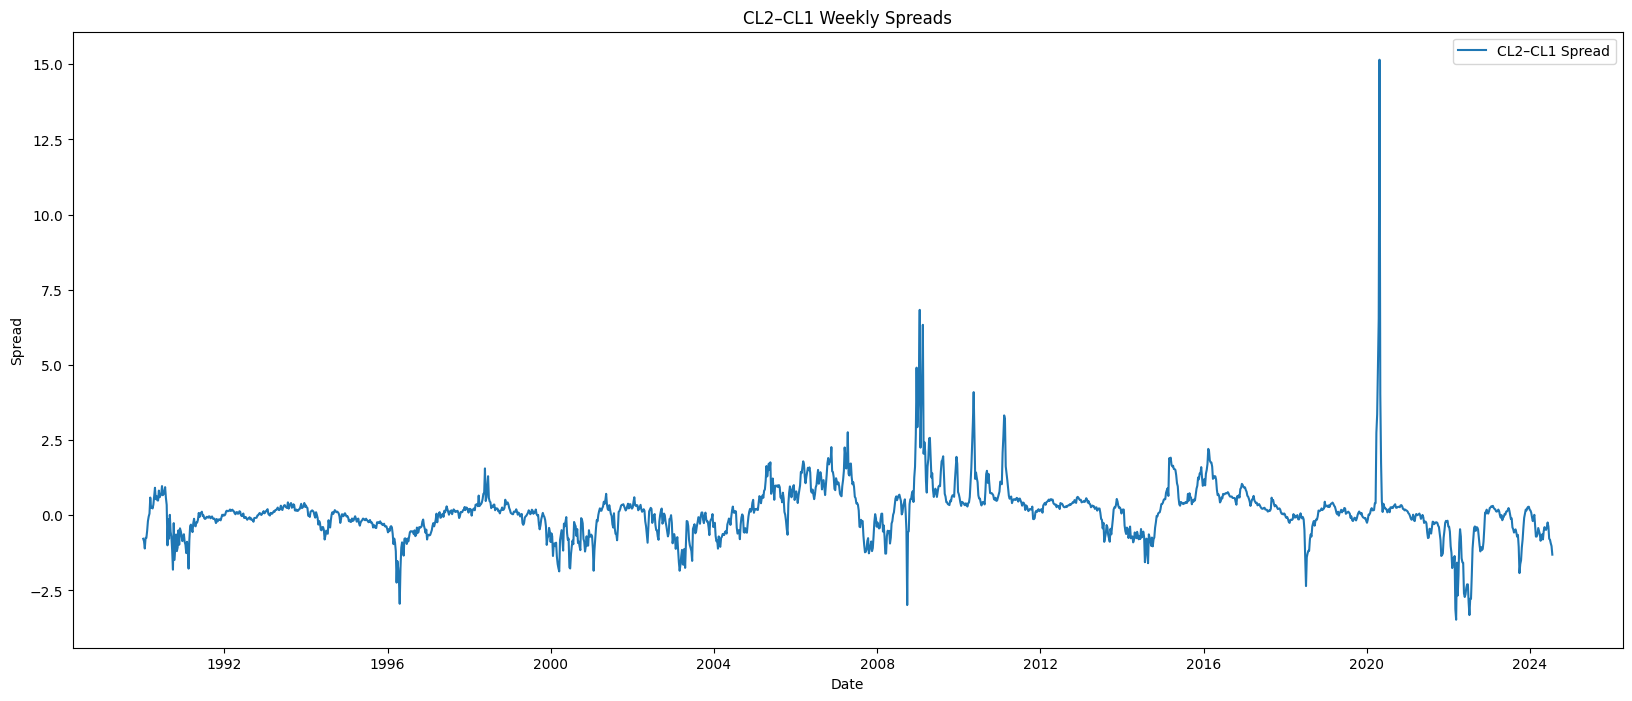

In [138]:
# Visulisaing spreads

plt.figure(figsize=(20, 8))
plt.plot(w["date"], w["spread"], label="CL2–CL1 Spread")
plt.xlabel("Date")
plt.ylabel("Spread")
plt.title("CL2–CL1 Weekly Spreads")
plt.legend()
plt.show()

# Diagnostics and Explanatory Variable Selection

## Splitting the data into training and testing set

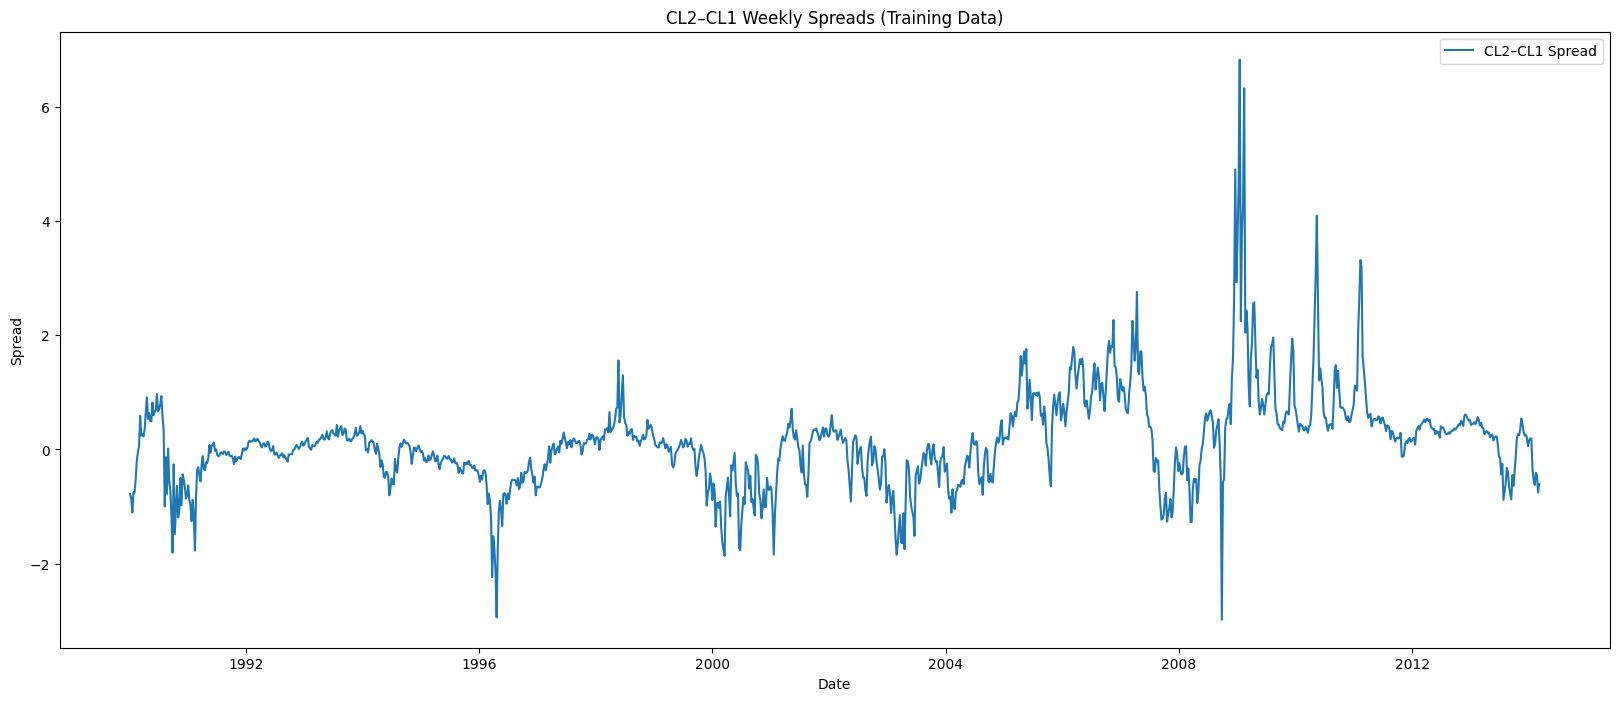

In [139]:
"""
Before we run any diagnostics and select any explanatory variables, we must start by splitting our data into a training 
and testing test. We should do this before running any diagonistics to prevent overfitting our data onto our testing 
sample and leading to unreliable out-of-sample results. 

We deice to utilise a 70:30 train:test split after observing the time-series plot above. The reason being that 
the training sample spans multiple market regimes, including periods of elevated volatility and structural stress, 
allowing the model to learn oil spread dynamics under diverse conditions. The test sample corresponds to a relatively 
stable regime, providing a rigourous evaluation of the model’s ability to generalise out of sample.
"""

# Create split slice
split = int(len(w) * 0.7)

# Creating training and testing sub-samples
w_train = w.iloc[:split]
w_test = w.iloc[split:]

# Plot training data to confirm split works
plt.figure(figsize=(20, 8))
plt.plot(w_train["date"], w_train["spread"], label="CL2–CL1 Spread")
plt.xlabel("Date")
plt.ylabel("Spread")
plt.title("CL2–CL1 Weekly Spreads (Training Data)")
plt.legend()
plt.show()


## Diagnostic Tests

### Test for Stationarity 

Test for Stationarity:

ADF (Augmented-Dickey Fuller) Test
$$
H_0: \delta = 0 \text{ (Suggests non-stationarity)}\\
H_1: \delta < 0 \text{ (Suggests stationarity)}
$$

KPSS (Kwiatkowski–Phillips–Schmidt–Shin) Test
$$
H_0: \delta = 0 \text{ (Suggests stationarity)}\\
H_1: \delta < 0 \text{ (Suggests non-stationarity)}
$$

In [140]:
# Test for Stationarity (ADF and KPSS Test)
from statsmodels.tsa.stattools import adfuller, kpss

# ADF
adf_result = adfuller(w_train["spread"].dropna())

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Critical Values:")
for key, value in adf_result[4].items():
    print(f"  {key}: {value}")


# KPSS
kpss_stat, kpss_pvalue, lags, crit = kpss(
    w_train["spread"].dropna(),
    regression="c",   # "c" = level stationarity, "ct" = trend stationarity
    nlags="auto"
)

print("KPSS Statistic:", kpss_stat)
print("p-value:", kpss_pvalue)
print("Critical Values:")
for key, value in crit.items():
    print(f"  {key}: {value}")


ADF Statistic: -4.166362451094361
p-value: 0.0007508204837884378
Critical Values:
  1%: -3.4356175602072545
  5%: -2.8638661490437025
  10%: -2.5680084710921105
KPSS Statistic: 1.3976603277284843
p-value: 0.01
Critical Values:
  10%: 0.347
  5%: 0.463
  2.5%: 0.574
  1%: 0.739


/var/folders/by/g895l7l128j9y19qqn66xcxh0000gn/T/ipykernel_33624/567564728.py:15: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_pvalue, lags, crit = kpss(


In [141]:
# Test for Stationarity (ADF and KPSS Test)
from statsmodels.tsa.stattools import adfuller, kpss

# Create a function for ADF and KPSS Test 
def stationarity_sum(series, name=""):
    series = series.dropna()

    adf = adfuller(series)
    kpss_stat, kpss_p, _, kpss_crit = kpss(series, regression="c", nlags="auto")

    print(f"\n{name}")
    print("-" * len(name))
    print(f"ADF p-value  : {adf[1]:.4f}")
    print(f"KPSS p-value : {kpss_p:.4f}")


stationarity_sum(w_train["spread"], "CL2-CL1 Spread")


CL2-CL1 Spread
--------------
ADF p-value  : 0.0008
KPSS p-value : 0.0100


/var/folders/by/g895l7l128j9y19qqn66xcxh0000gn/T/ipykernel_33624/3964951594.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, _, kpss_crit = kpss(series, regression="c", nlags="auto")


The ADF test rejects the null of a unit root, while the KPSS test rejects the null of stationarity, suggesting that the series is mean-reverting but exhibits structural breaks or regime-dependent behaviour. <br>

We will difference the data and test for stationarity again for rigidness

In [142]:
# Difference the time-series
spread_d = w_train["spread"].diff().dropna()

stationarity_sum(spread_d, "CL2-CL1 Spread (Differenced)")


CL2-CL1 Spread (Differenced)
----------------------------
ADF p-value  : 0.0000
KPSS p-value : 0.1000


/var/folders/by/g895l7l128j9y19qqn66xcxh0000gn/T/ipykernel_33624/3964951594.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, kpss_crit = kpss(series, regression="c", nlags="auto")


Now both the ADF and KPSS test both suggest that there is enough statistical evidence at the 5% alpha, which suggests that when the time-series is differenced to the first degree (I=1), the time-series is stationary.<br>

Although first differencing yields statistically stationary behaviour, oil calendar spreads are theoretically mean-reverting. The spread is therefore modelled in levels as the primary specification, with differenced models estimated as robustness checks.<br>

However, moving forward, we will do perform out-of-sample forecasts using both models and see which model has higher predictive power [i.e. SARIMAX(p,0,q) and SARIMAX(p,1,q)].

### ACF and PACF Plot

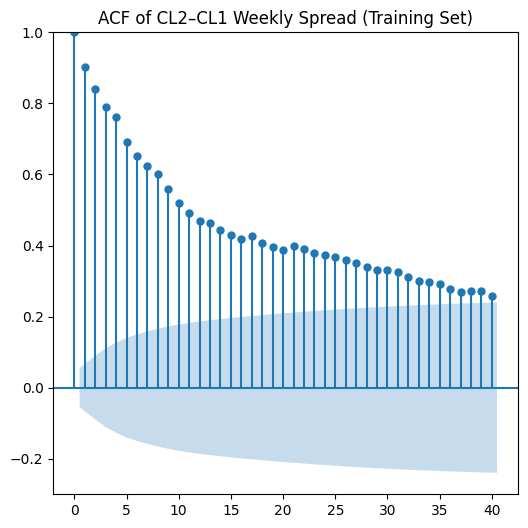

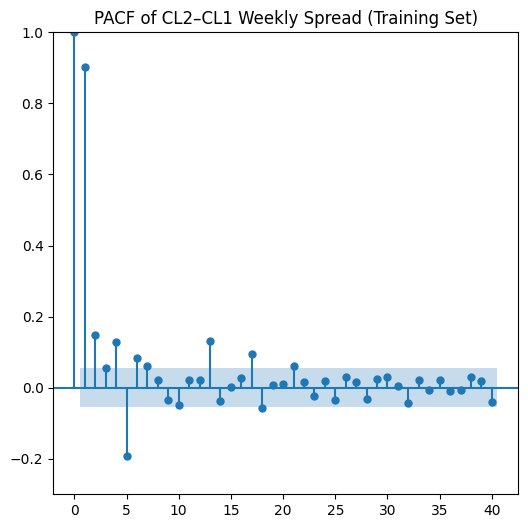

In [143]:
# ACF and PACF Plots
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, ax = plt.subplots(figsize=(6, 6))
plot_acf(w_train["spread"], lags=40, ax=ax)
ax.set_title("ACF of CL2–CL1 Weekly Spread (Training Set)")
plt.ylim(-0.3,1)
plt.show()

fig, ax = plt.subplots(figsize=(6, 6))
plot_pacf(w_train["spread"], lags=40, ax=ax)
ax.set_title("PACF of CL2–CL1 Weekly Spread (Training Set)")
plt.ylim(-0.3,1)
plt.show()


## Auto-ARIMA Optimal Lag Choice

In [148]:
# Define the maximum number of lags to consider
max_lags = 10

# Function to find the best ARIMA order using different information criteria
def auto_arima_lag(series, max_lags, criterion):
    model = pm.auto_arima(
        series,
        start_p=0, start_q=0,
        max_p=max_lags, max_q=max_lags,
        seasonal=False,
        stepwise=True,
        suppress_warnings=True,
        information_criterion=criterion
    )
    return model.order

# Find the best ARIMA order using AIC, BIC, and HQIC
orders = {
    'AIC': auto_arima_lag(w_train['spread'], max_lags, 'aic'),
    'BIC': auto_arima_lag(w_train['spread'], max_lags, 'bic'),
    'HQIC': auto_arima_lag(w_train['spread'], max_lags, 'hqic')
}

# Print the selected ARIMA order
for criterion, order in orders.items():
    print(f'{criterion}: {order}')

AIC: (5, 1, 1)
BIC: (5, 1, 1)
HQIC: (5, 1, 5)


## Selecting Explanatory/Exogenous Variables

In [ ]:
"""
Gauss-Markov Theorem:
1. E[u_t] = 0, Errors have a mean of 0
2. Var(u_t) = 0, Errors are homoskedastic, i.e. errors have a constant variance
3. Cov (u_t, v_t) = 0, Errors are uncorrelated to one another
4. Cov(u_t, x_t) = 0, Error term and explanatory variables should be uncorrelated to each other
5. Error term should follow a Guassian Distribution

The following tests that we run will keep the following in mind and test for diagnostics, such as 
multicollinearity and standard error robustness to ensure that our model is as accurate as possible, whilst maintaining a relative alignment
to the G-M assumptions
"""

for exog in [macro, prices]:
    exog.index = pd.to_datetime(exog.index)
    exog.sort_index(inplace=True)

exog = pd.concat(
    [
        macro,
        prices
    ],
    axis=1
)

# Correlation Matrix (for exogenous variables)
exog_corr = exog.corr()
print(exog_corr)




                                Date  CPI YOY %  3M Yield  10Y Yield  \
Date                        1.000000   0.153474 -0.495464  -0.802910   
CPI YOY %                   0.153474   1.000000  0.288152   0.150046   
3M Yield                   -0.495464   0.288152  1.000000   0.833421   
10Y Yield                  -0.802910   0.150046  0.833421   1.000000   
IndustrialProduction Index  0.802742   0.190989 -0.387466  -0.661491   
SPX                         0.856914   0.388766 -0.105672  -0.487068   
DXY returns                 0.025087   0.128692  0.012650   0.007717   
VIX                        -0.101018  -0.038288 -0.159270  -0.064148   
Date                        1.000000   0.153488 -0.495465  -0.802909   
Gasoline All Grades         0.769605   0.352713 -0.436786  -0.607224   
Dow Jones US Oil&Gas Index  0.769158   0.141437 -0.409735  -0.592297   
ExxonMobil                  0.783706   0.125072 -0.362901  -0.577610   
ConocoPhilips               0.825675   0.398052 -0.165756  -0.45